# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals
---
* **Author**: Carmen-Theodora Craciun
* **The purpose of this Notebook**: This notebook handles ...
* **Datasets**: [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) and [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/)
    * Sleep Cassette (SC) - the study on healthy people;
    * Sleep Telemetry (ST) - sleep study in people with difficulty falling asleep. This study was designed to look at the effects of temazepam, a drug with hypnotic effects;
    * UCDDB - patients diagnosed with apnea, who do not suffer from cardiological diseases or autonomic dysfunctions and are not taking medication at the time of registration.
* **Input**:
  * class_distribution.csv
  * results.zip - a compressed archive containing the layered and prepared dataset for training (train, test, val)
    * each file in these folders represents a *processed sleep window* (epoch)
* **Output:**
  * `model_bilstm_baseline.pt`
  * `model_crnn.pt`
  * `model_resnet.pt`

# Imports

In [29]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [30]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

In [31]:
test_path_csv = 'process_dataset/extracted_features/test_features.csv'
test_path_raw = 'process_dataset/test'
class_distribution_path = 'process_dataset/class_distribution_train.csv'

In [32]:
import utils

In [5]:
# Results Dataframe

In [33]:
results = pd.read_csv("./model_results.csv")

results['test_acc'] = None
results['test_kappa'] = None
results["roc_fpr"] = None
results["roc_tpr"] = None
results["roc_auc"] = None

display(results.head(3))

,name,type,acc_mean,acc_std,kappa_mean,kappa_std,acc_best,kappa_best,fold_accs,fold_kappas,path,test_acc,test_kappa,roc_fpr,roc_tpr,roc_auc
0,LGBM,Tree-Based,0.771113,0.011058,0.688753,0.015881,0.785777,0.711319,"[0.7822102234378885, 0.7665833392014647, 0.756...","[0.7028607198228597, 0.6815896297628314, 0.668...",models/best_LGBM_calibrated.pkl,None,None,None,None,None
1,XGB,Tree-Based,0.770371,0.010155,0.688016,0.014584,0.783613,0.708600,"[0.7801854285815779, 0.7679388775438349, 0.756...","[0.7002627188458095, 0.6838012033399608, 0.668...",./models/best_XGB_calibrated.pkl,None,None,None,None,None
2,RF,Tree-Based,0.743268,0.011200,0.650749,0.016184,0.760179,0.676338,"[0.7523533799865013, 0.7389444405323569, 0.730...","[0.6624766935630217, 0.6433002138925756, 0.633...",./models/best_RF_calibrated.pkl,None,None,None,None,None


In [42]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
def compute_roc_df(y_true, y_proba):
    # 1. Binarizezi etichetele
    y_bin = label_binarize(y_true, classes=[0,1,2,3,4])
    
    # 2. Calculezi ROC pentru fiecare clasă
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(5):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    return fpr, tpr, roc_auc

# Dataset

In [35]:
df_test = pd.read_csv(test_path_csv)
cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']
feature_cols = [c for c in df_test.columns if c not in cols_to_drop]
X_test = df_test[feature_cols]
y_test = df_test['Label']
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test.fillna(0))
X_test_seq, y_test_seq, _ = utils.build_sequences_per_subject(df_test, feature_cols, seq_len=30, step=5)

# Models test

## LightGBM

Accuracy 0.7811

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.87      0.82      7687
          N1       0.52      0.27      0.36      5307
          N2       0.79      0.90      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.80      0.78      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



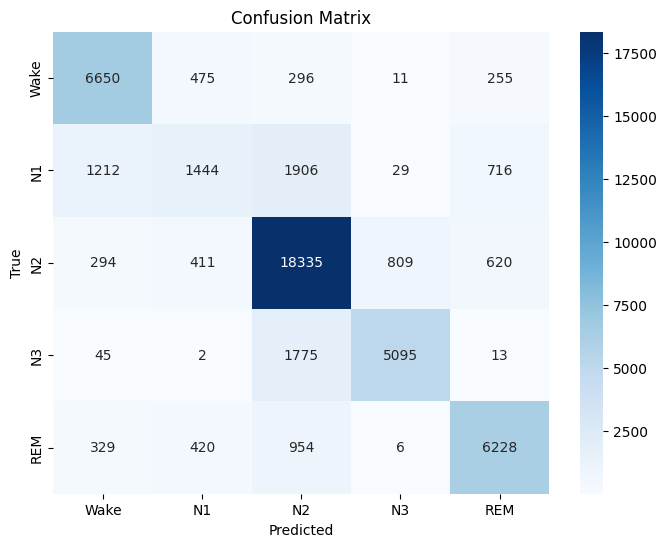

Cohen's Kappa: 0.694964806891643


In [36]:
mask = (results['name'] == 'LGBM')
lgbm_model = joblib.load(results.loc[mask,'path'].values[0])
# Predict calibrated probabilities
y_proba_lgbm = lgbm_model.predict_proba(X_test)
# Predict final class
y_pred_test_lgm = lgbm_model.predict(X_test)
# Save metrics
results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_test, y_pred_test_lgm)
# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_test, y_proba_lgbm)
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

## XGBoost

Accuracy 0.7804

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.86      0.82      7687
          N1       0.52      0.28      0.36      5307
          N2       0.79      0.89      0.84     20469
          N3       0.85      0.73      0.79      6930
         REM       0.79      0.79      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



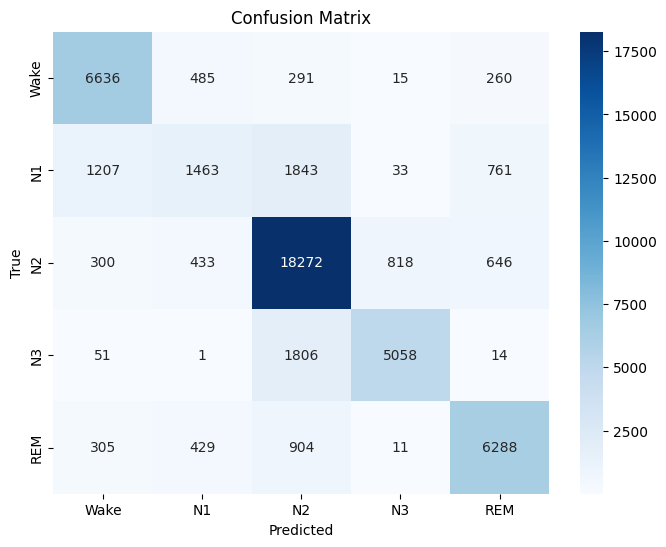

Cohen's Kappa: 0.6943225033954341


In [37]:
mask = (results['name'] == 'XGB')
xgb_model = joblib.load(results.loc[mask,'path'].values[0])
# Predict calibrated probabilities
y_proba_xgb = xgb_model.predict_proba(X_test)
# Predict final class
y_pred_test_xgb = xgb_model.predict(X_test)
results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_test, y_pred_test_xgb)
# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_test, y_proba_xgb)
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

## Random Forest

Accuracy 0.7523

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.72      0.82      0.77      7687
          N1       0.49      0.24      0.32      5307
          N2       0.78      0.87      0.82     20469
          N3       0.85      0.70      0.77      6930
         REM       0.74      0.79      0.76      7937

    accuracy                           0.75     48330
   macro avg       0.71      0.68      0.69     48330
weighted avg       0.74      0.75      0.74     48330



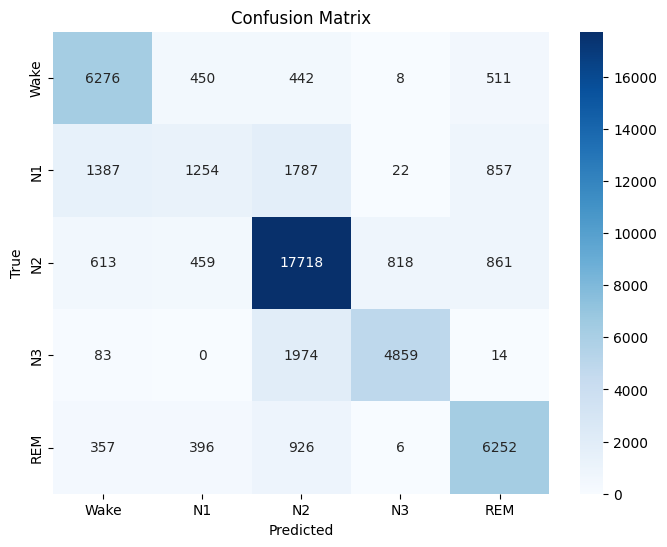

Cohen's Kappa: 0.6557300761808108


In [38]:
mask = (results['name'] == 'RF')
rf_model = joblib.load(results.loc[mask,'path'].values[0])
# Predict calibrated probabilities
y_proba_rf = rf_model.predict_proba(X_test)
# Predict final class
y_pred_test_rf = rf_model.predict(X_test)
# utils.evaluate_model(y_test, )
results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_test, y_pred_test_rf)

# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_test, y_proba_rf)
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

## LDA

Accuracy 0.7352

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.76      0.72      0.74      7687
          N1       0.41      0.31      0.35      5307
          N2       0.77      0.85      0.81     20469
          N3       0.79      0.69      0.74      6930
         REM       0.72      0.79      0.75      7937

    accuracy                           0.74     48330
   macro avg       0.69      0.67      0.68     48330
weighted avg       0.73      0.74      0.73     48330



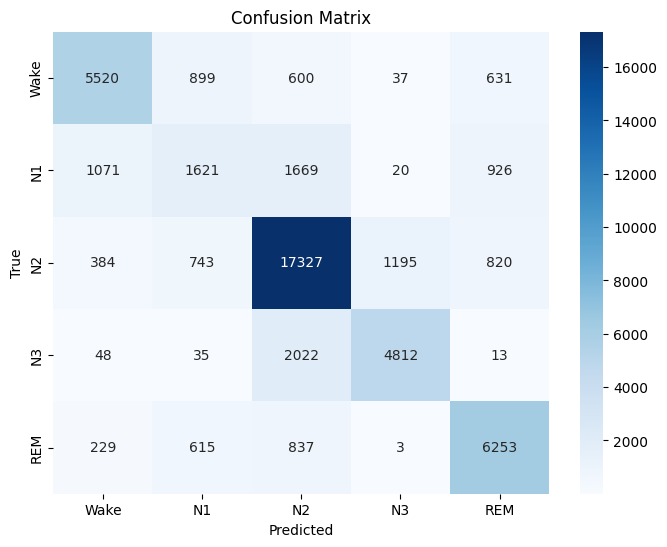

Cohen's Kappa: 0.633819693313449


In [39]:
mask = (results['name'] == 'LDA')
lda_model = joblib.load(results.loc[mask,'path'].values[0])
# Predict calibrated probabilities
y_proba_lda = lda_model.predict_proba(X_test_scaled)
# Predict final class
y_pred_test_lda = lda_model.predict(X_test_scaled)
results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_test, y_pred_test_lda)

# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_test, y_proba_lda)
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

## Logistic Regression

Accuracy 0.7213

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.73      0.74      7687
          N1       0.35      0.44      0.39      5307
          N2       0.87      0.72      0.79     20469
          N3       0.72      0.84      0.77      6930
         REM       0.69      0.81      0.75      7937

    accuracy                           0.72     48330
   macro avg       0.68      0.71      0.69     48330
weighted avg       0.74      0.72      0.73     48330



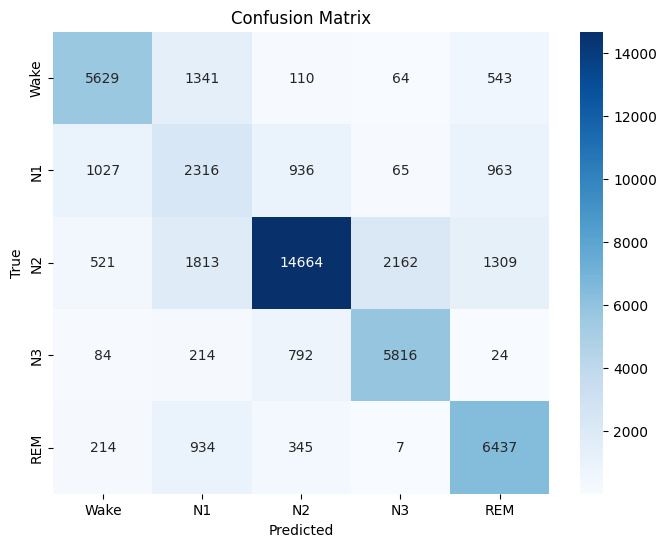

Cohen's Kappa: 0.6319456980956805


In [40]:
mask = (results['name'] == 'LR')
lr_model = joblib.load(results.loc[mask,'path'].values[0])
# Predict calibrated probabilities
y_proba_lr = lr_model.predict_proba(X_test_scaled)
# Predict final class
y_pred_test_lr = lr_model.predict(X_test_scaled)
# utils.evaluate_model(y_test, y_pred_test_lr)
results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_test, y_pred_test_lr)

# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_test, y_proba_lr)
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

## MLP

1511/1511 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Accuracy 0.7842

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.77      0.88      0.82      7687
          N1       0.51      0.32      0.39      5307
          N2       0.81      0.88      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.79      0.80      0.80      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.72      0.73     48330
weighted avg       0.77      0.78      0.77     48330



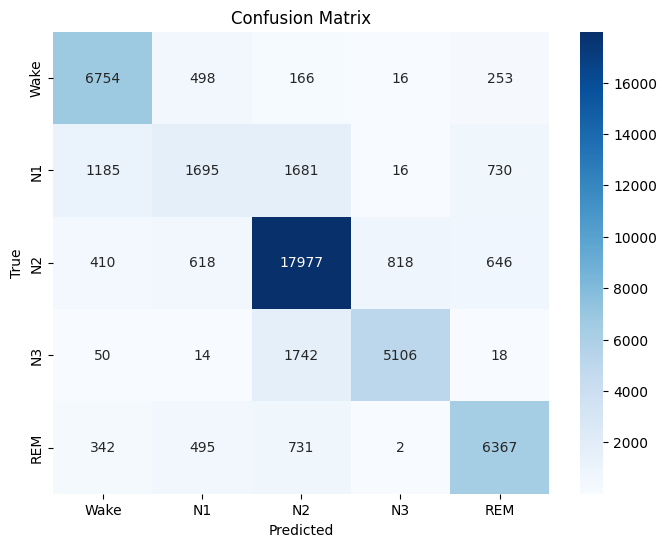

Cohen's Kappa: 0.7016423438953987


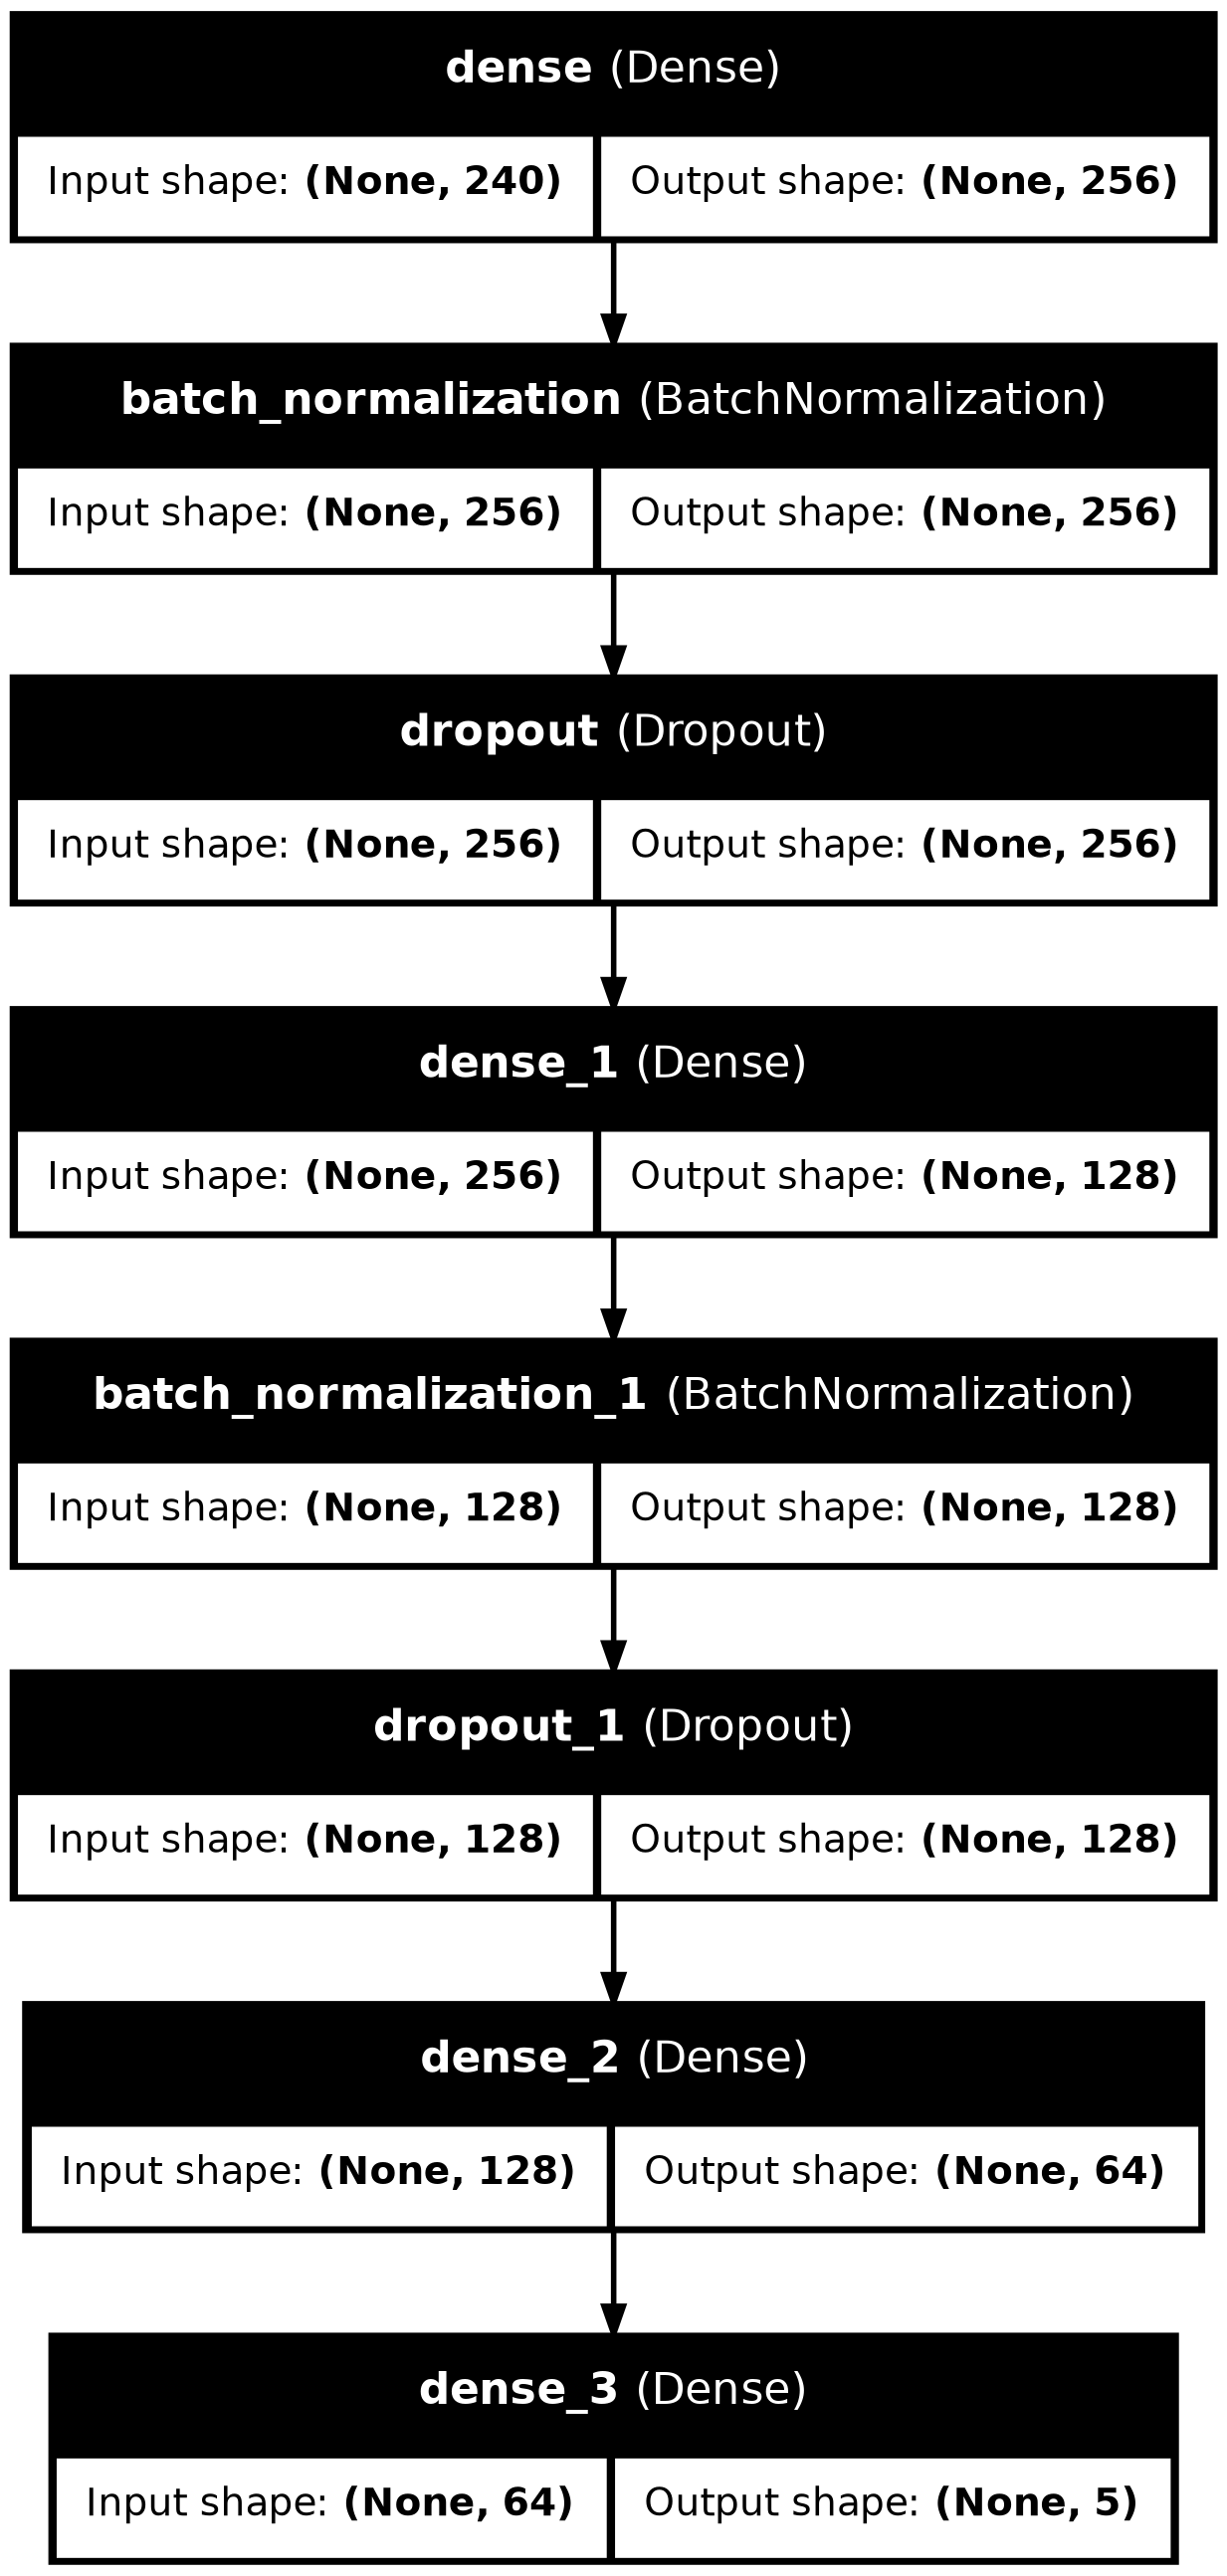

In [43]:
mask = (results['name'] == 'MLP')
mlp_model = load_model(results.loc[mask,'path'].values[0])
y_proba_mlp = mlp_model.predict(X_test)
y_pred_mlp = y_proba_mlp.argmax(axis=1)
# utils.evaluate_model(y_test, y_pred_mlp)
results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_test, y_pred_mlp)

# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_test, y_proba_mlp)
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

plot_model(
    mlp_model,
    to_file="architecture_mlp.png",
    show_shapes=True,
    show_layer_names=True
)

## LSTM

292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step
Accuracy 0.7889

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.89      0.84      1395
          N1       0.53      0.26      0.35       977
          N2       0.80      0.86      0.83      3996
          N3       0.80      0.76      0.78      1387
         REM       0.82      0.86      0.84      1585

    accuracy                           0.79      9340
   macro avg       0.75      0.73      0.73      9340
weighted avg       0.77      0.79      0.78      9340



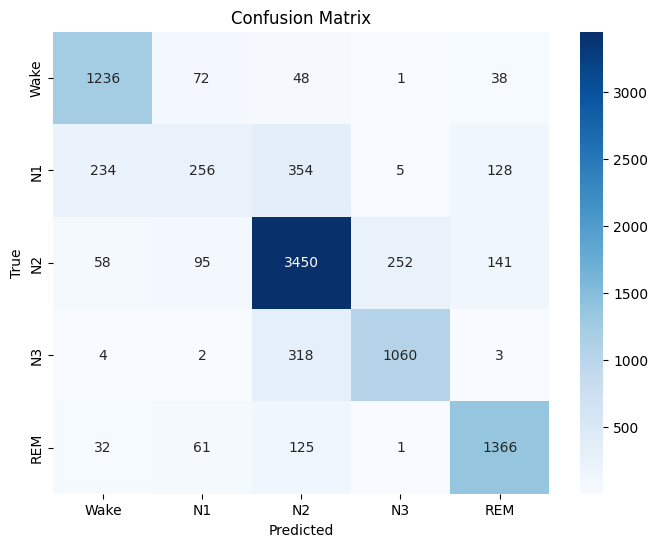

Cohen's Kappa: 0.7073192048372909


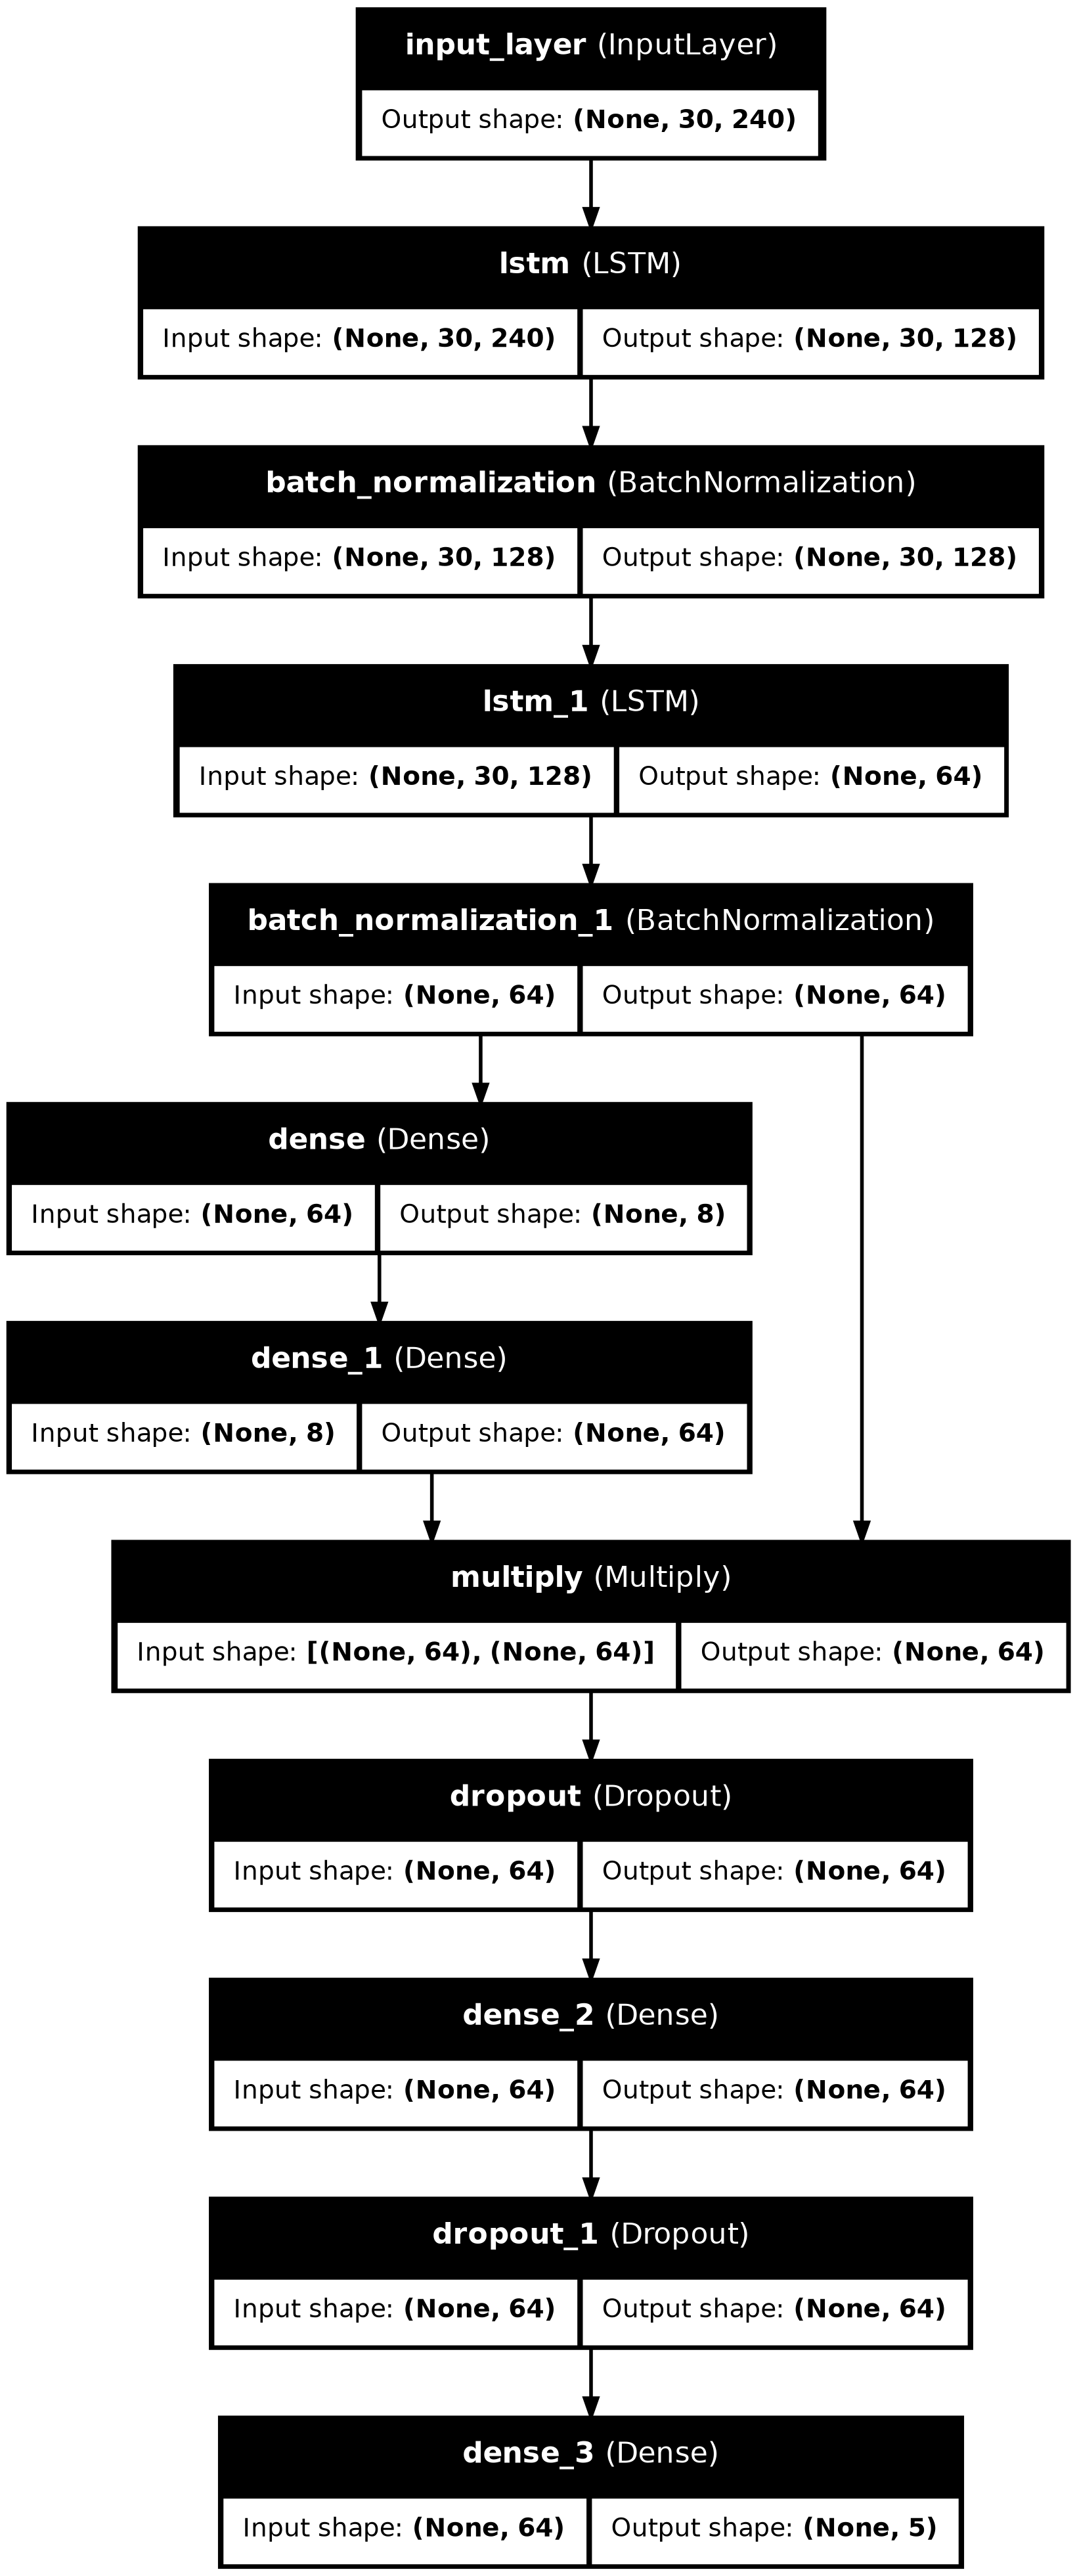

In [44]:
mask = (results['name'] == 'LSTM')
lstm_model = load_model(
    results.loc[mask,'path'].values[0],
    custom_objects={
        "se_feature_attention": utils.se_feature_attention,
        "focal_loss": utils.focal_loss
    },
    compile=False
)

y_proba_lstm = lstm_model.predict(X_test_seq)
y_pred_test_lstm = y_proba_lstm.argmax(axis=1)

results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_test_seq, y_pred_test_lstm)

# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_test_seq, y_proba_lstm)
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

plot_model(
    lstm_model,
    to_file="architecture_lstm.png",
    show_shapes=True,
    show_layer_names=True
)

## ResNet

292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Accuracy 0.7819

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.83      0.81      1395
          N1       0.46      0.34      0.39       977
          N2       0.80      0.87      0.83      3996
          N3       0.82      0.77      0.79      1387
         REM       0.84      0.81      0.82      1585

    accuracy                           0.78      9340
   macro avg       0.74      0.72      0.73      9340
weighted avg       0.77      0.78      0.78      9340



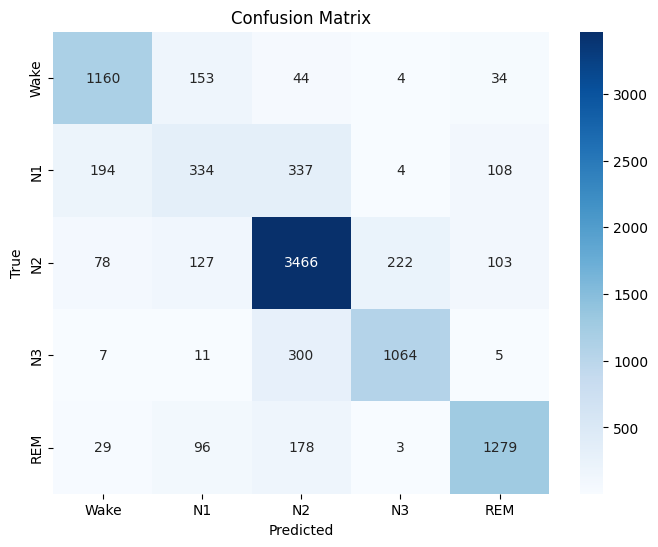

Cohen's Kappa: 0.6979022223540492


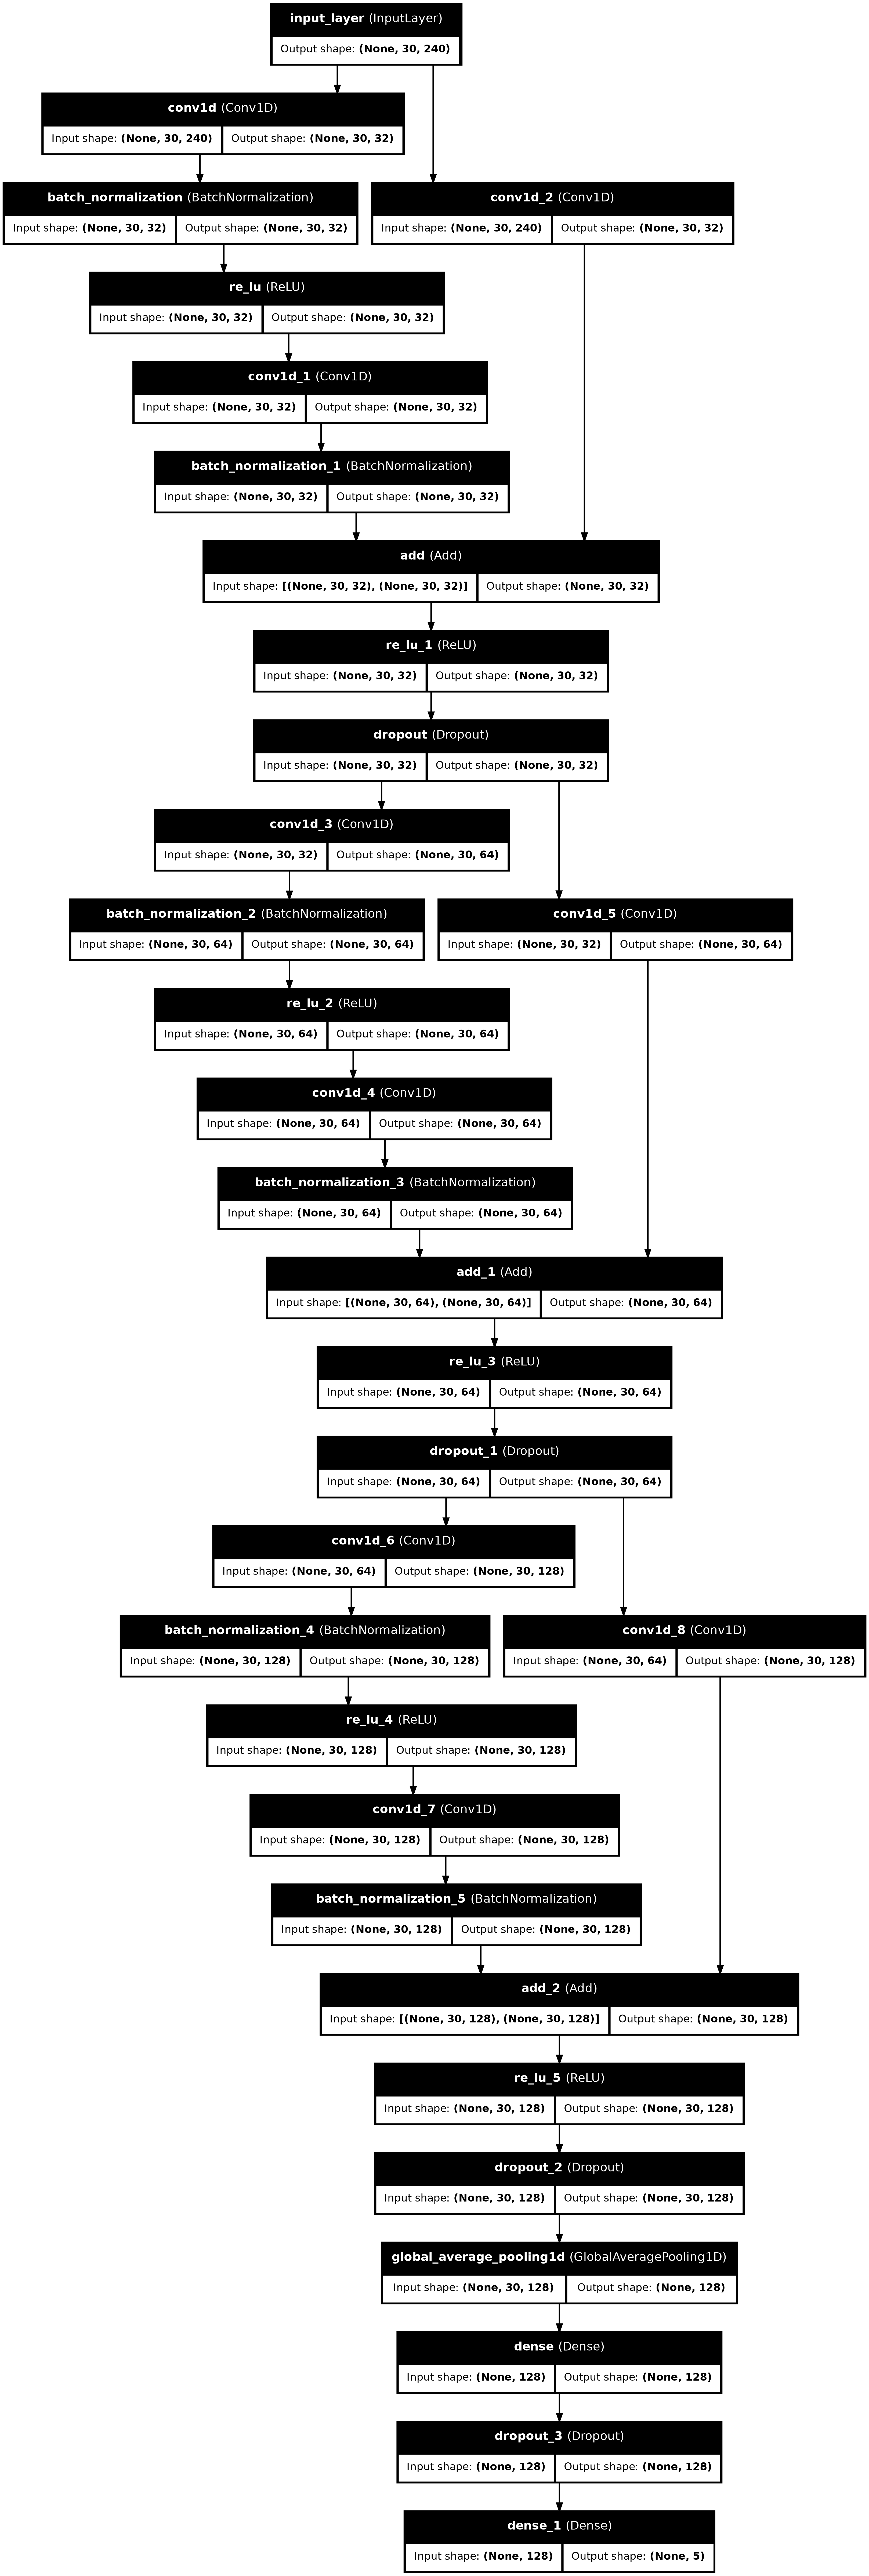

In [45]:
mask = (results['name'] == 'ResNet')
resnet_model = load_model(
    results.loc[mask,'path'].values[0],
    compile=False
)
y_proba_resnet = resnet_model.predict(X_test_seq)
y_pred_test_resnet = y_proba_resnet.argmax(axis=1)
results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_test_seq, y_pred_test_resnet)

# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_test_seq, y_proba_resnet)
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

plot_model(
    resnet_model,
    to_file="architecture_resnet.png",
    show_shapes=True,
    show_layer_names=True
)

## 1D-CNN

57/57 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step
Accuracy 0.7704

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.73      0.94      0.82      7621
          N1       0.51      0.19      0.27      5260
          N2       0.80      0.87      0.83     20468
          N3       0.79      0.77      0.78      6930
         REM       0.77      0.75      0.76      7937

    accuracy                           0.77     48216
   macro avg       0.72      0.70      0.69     48216
weighted avg       0.75      0.77      0.75     48216



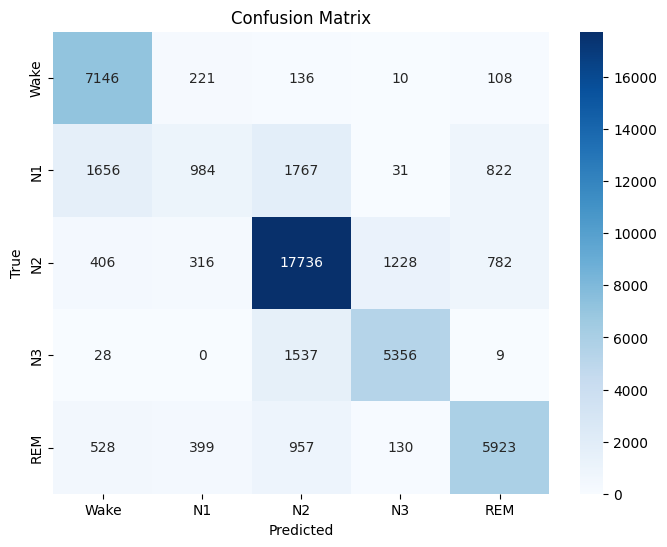

Cohen's Kappa: 0.6822190193653697


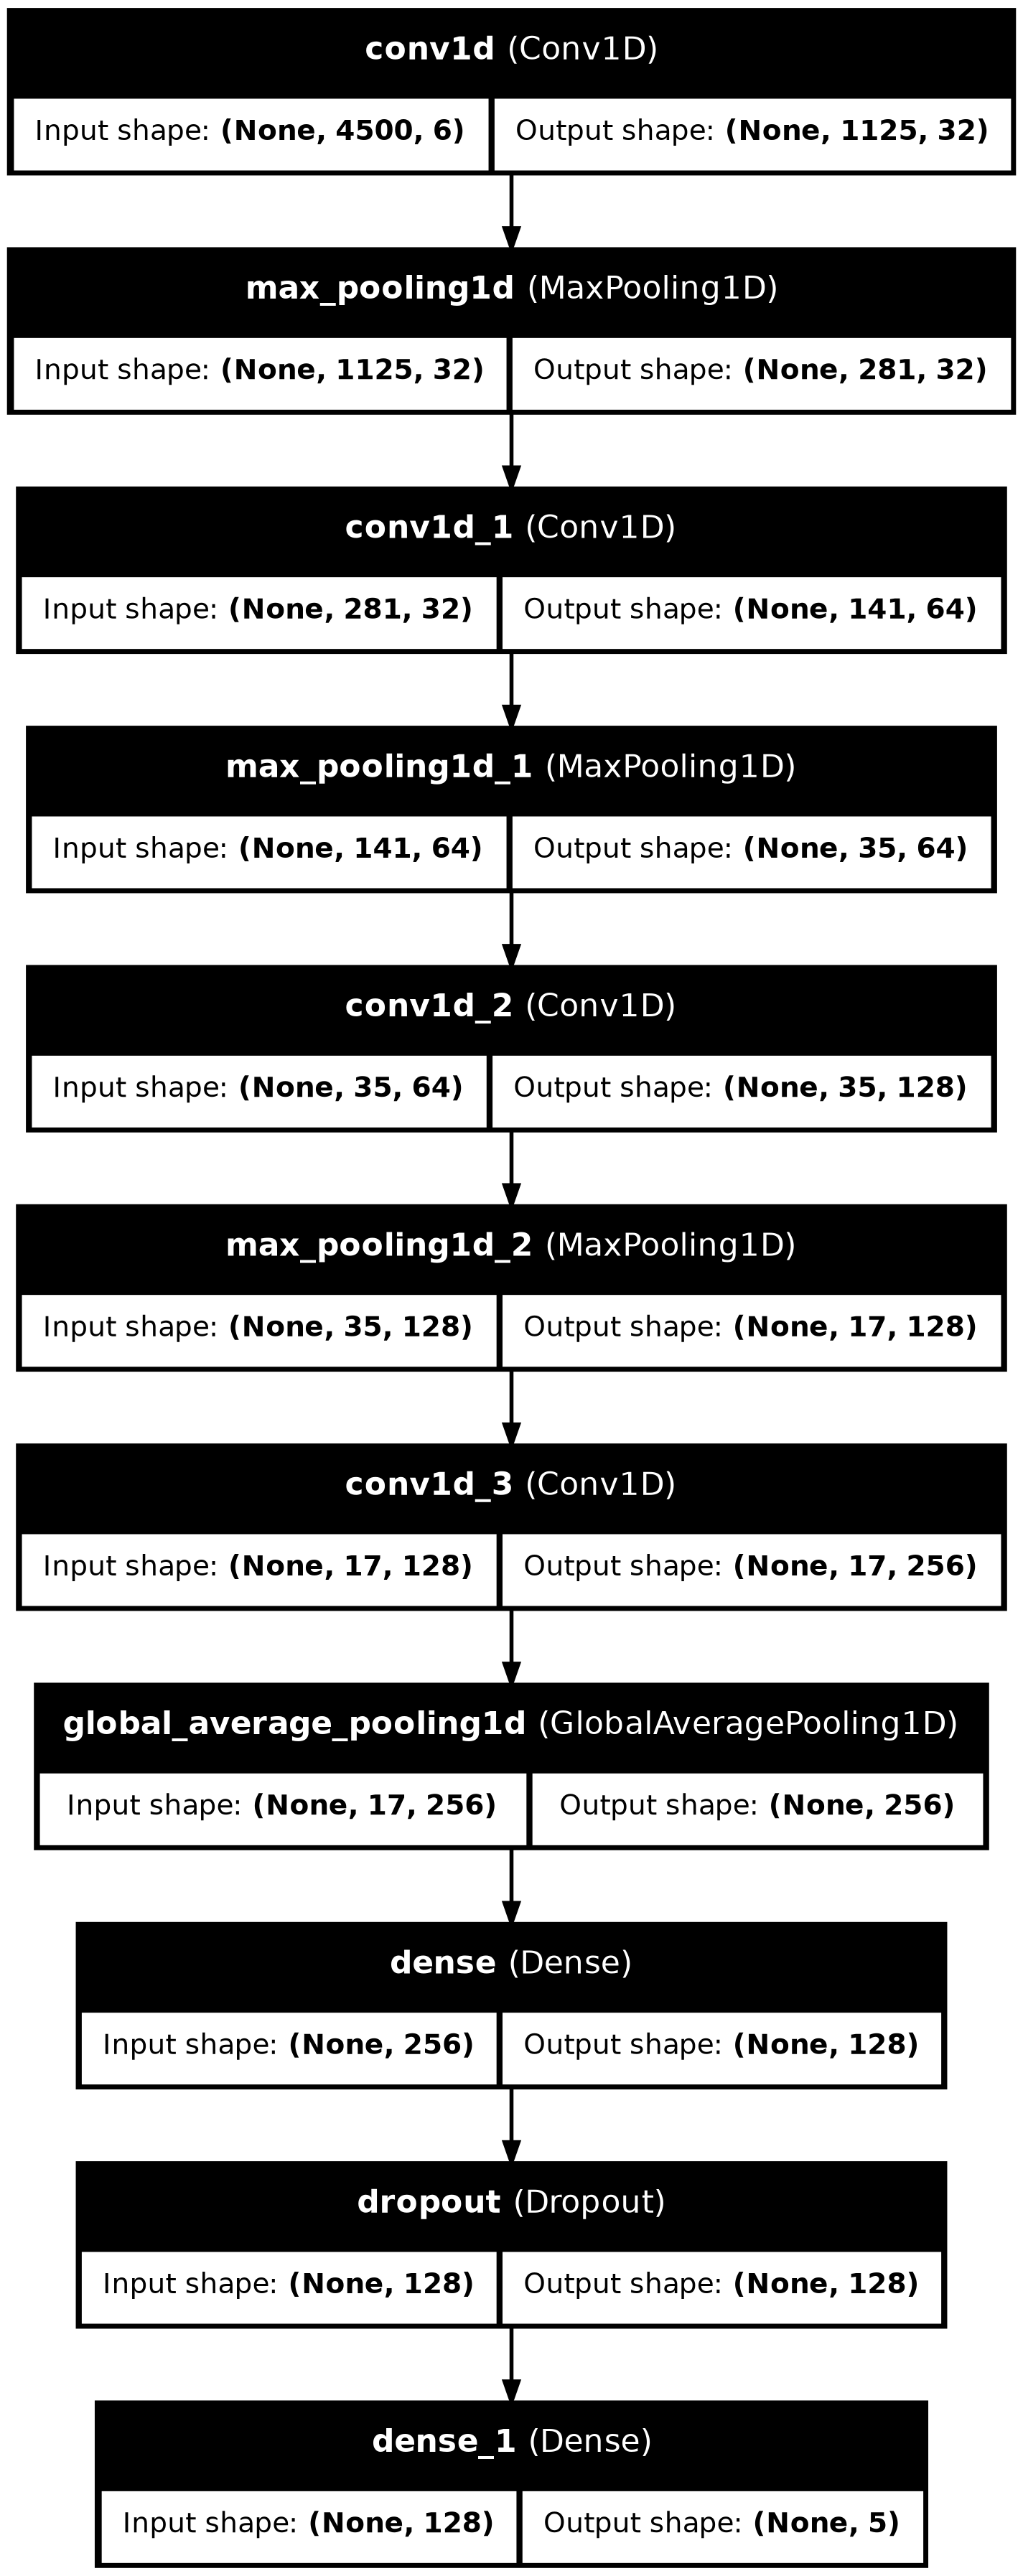

In [46]:
test_gen = utils.SleepDataGenerator(
    test_path_raw,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

mask = (results['name'] == 'CNN')
cnn_model = load_model(results.loc[mask,'path'].values[0], compile=False)

# Predict probabilities
y_proba_cnn = cnn_model.predict(test_gen)

# Predict final class
y_pred_cnn = y_proba_cnn.argmax(axis=1)

# Extract true labels from generator
y_true_cnn = []
for i in range(len(test_gen)):
    _, y_batch = test_gen[i]
    y_true_cnn.extend(np.argmax(y_batch, axis=1))
y_true_cnn = np.array(y_true_cnn)

# Save metrics
results.loc[mask,'test_acc'], results.loc[mask,'test_kappa'] = utils.evaluate_model(y_true_cnn, y_pred_cnn)

# Compute ROC
fpr, tpr, roc_auc = compute_roc_df(y_true_cnn, y_proba_cnn)

# Save ROC in DataFrame
results.loc[mask, "roc_fpr"] = [fpr]
results.loc[mask, "roc_tpr"] = [tpr]
results.loc[mask, "roc_auc"] = [roc_auc]

from tensorflow.keras.utils import plot_model

plot_model(
    cnn_model,
    to_file="architecture_cnn.png",
    show_shapes=True,
    show_layer_names=True
)


# Ensemble

In [55]:
import numpy as np

def ensemble_weight_search(y_true, y_proba_A, y_proba_B):
    best_w = None
    best_kappa = -999
    best_acc = -999

    for w in np.linspace(0, 1, 21):  # 0.00, 0.05, ..., 1.00
        y_proba_ens = w * y_proba_A + (1 - w) * y_proba_B
        y_pred_ens = y_proba_ens.argmax(axis=1)

        acc, kappa = utils.evaluate_model(y_true, y_pred_ens,diable_view=False)

        if kappa > best_kappa:
            best_kappa = kappa
            best_acc = acc
            best_w = w

    return best_w, best_acc, best_kappa

In [ ]:
## LGBM + MLP

In [67]:
best_w, best_acc, best_kappa = ensemble_weight_search(
    y_test,
    y_proba_lgbm,
    y_proba_mlp
)

print("Best weight:", best_w)
print("Best acc:", best_acc)
print("Best kappa:", best_kappa)

Best weight: 0.35000000000000003
Best acc: 0.7904614111318022
Best kappa: 0.7092007290632181


Accuracy 0.7905

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.89      0.83      7687
          N1       0.55      0.30      0.39      5307
          N2       0.80      0.89      0.84     20469
          N3       0.87      0.74      0.80      6930
         REM       0.80      0.81      0.80      7937

    accuracy                           0.79     48330
   macro avg       0.76      0.73      0.73     48330
weighted avg       0.78      0.79      0.78     48330



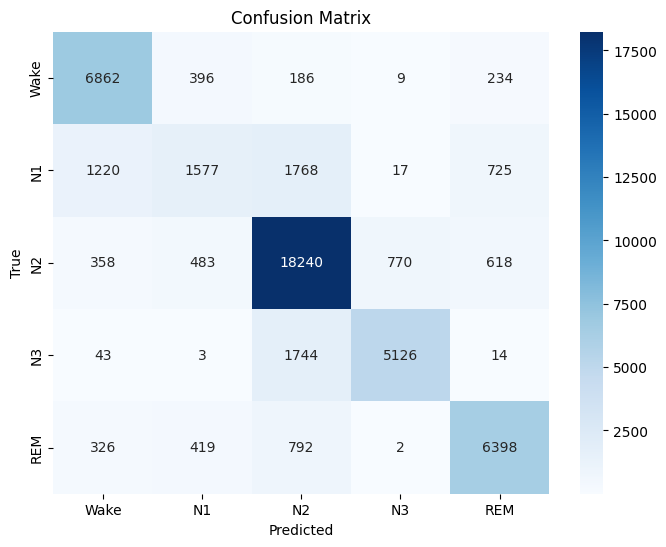

Cohen's Kappa: 0.7092007290632181


In [68]:
y_proba_ens = best_w * y_proba_lgbm + (1 - best_w) * y_proba_mlp
y_pred_ens = y_proba_ens.argmax(axis=1)

acc_ens, kappa_ens = utils.evaluate_model(y_test, y_pred_ens)
fpr_ens, tpr_ens, roc_auc_ens = compute_roc_df(y_test, y_proba_ens)

results.loc[len(results)] = {
    "name": "LGBM_MLP",
    "type": "Ensemble",
    "test_acc": acc_ens,
    "test_kappa": kappa_ens,
    "roc_fpr": [fpr_ens],
    "roc_tpr": [tpr_ens],
    "roc_auc": [roc_auc_ens],
    "path": None
}

## LSTM + ResNet

In [69]:
best_w, best_acc, best_kappa = ensemble_weight_search(
    y_test_seq,
    y_proba_lstm,
    y_proba_resnet
)

print("Best weight:", best_w)
print("Best acc:", best_acc)
print("Best kappa:", best_kappa)

Best weight: 0.65
Best acc: 0.797644539614561
Best kappa: 0.7193767444068297


Accuracy 0.7976

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.81      0.87      0.84      1395
          N1       0.54      0.33      0.41       977
          N2       0.81      0.87      0.84      3996
          N3       0.82      0.78      0.80      1387
         REM       0.83      0.85      0.84      1585

    accuracy                           0.80      9340
   macro avg       0.76      0.74      0.74      9340
weighted avg       0.79      0.80      0.79      9340



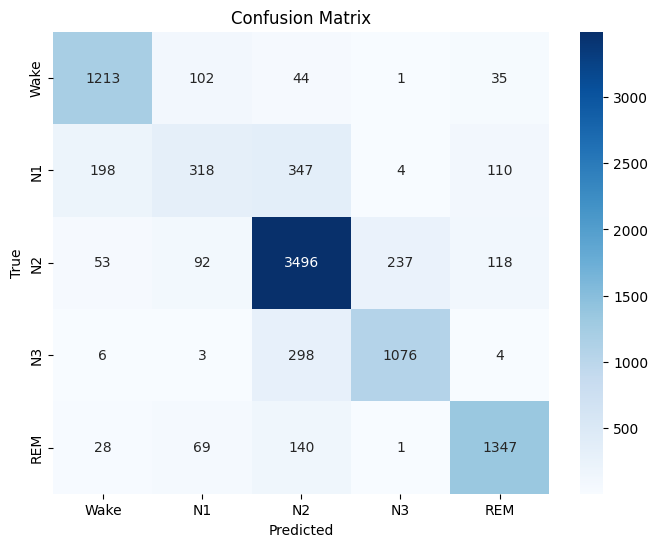

Cohen's Kappa: 0.7193767444068297


In [70]:
y_proba_ens = best_w * y_proba_lstm + (1 - best_w) * y_proba_resnet
y_pred_ens = y_proba_ens.argmax(axis=1)

acc_ens, kappa_ens = utils.evaluate_model(y_test_seq, y_pred_ens)
fpr_ens, tpr_ens, roc_auc_ens = compute_roc_df(y_test_seq, y_proba_ens)

results.loc[len(results)] = {
    "name": "LSTM_ResNet",
    "type": "Ensemble",
    "test_acc": acc_ens,
    "test_kappa": kappa_ens,
    "roc_fpr": [fpr_ens],
    "roc_tpr": [tpr_ens],
    "roc_auc": [roc_auc_ens],
    "path": None
}

In [71]:
display(results)
results.to_csv("./model_results.csv", index=False)

,name,type,acc_mean,acc_std,kappa_mean,kappa_std,acc_best,kappa_best,fold_accs,fold_kappas,path,test_acc,test_kappa,roc_fpr,roc_tpr,roc_auc
0,LGBM,Tree-Based,0.771113,0.011058,0.688753,0.015881,0.785777,0.711319,"[0.7822102234378885, 0.7665833392014647, 0.756...","[0.7028607198228597, 0.6815896297628314, 0.668...",models/best_LGBM_calibrated.pkl,0.78113,0.694965,"{0: [0.0, 0.0, 0.0, 2.4604482936791083e-05, 2....","{0: [0.0, 0.00013008976193573565, 0.0552881488...","{0: 0.9755349659389868, 1: 0.827816012855574, ..."
1,XGB,Tree-Based,0.770371,0.010155,0.688016,0.014584,0.783613,0.708600,"[0.7801854285815779, 0.7679388775438349, 0.756...","[0.7002627188458095, 0.6838012033399608, 0.668...",./models/best_XGB_calibrated.pkl,0.780406,0.694323,"{0: [0.0, 0.0, 0.0, 2.4604482936791083e-05, 2....","{0: [0.0, 0.00013008976193573565, 0.0555483283...","{0: 0.9760877297981325, 1: 0.8367646709151294,..."
2,RF,Tree-Based,0.743268,0.011200,0.650749,0.016184,0.760179,0.676338,"[0.7523533799865013, 0.7389444405323569, 0.730...","[0.6624766935630217, 0.6433002138925756, 0.633...",./models/best_RF_calibrated.pkl,0.752307,0.65573,"{0: [0.0, 0.0, 0.0, 0.0, 0.0, 2.46044829367910...","{0: [0.0, 0.0006504488096786782, 0.00195134642...","{0: 0.965282392807635, 1: 0.8329937290040098, ..."
3,LDA,Probabilistic,0.725145,0.011499,0.627578,0.016048,0.739103,0.646720,"[0.7391034066285389, 0.7233997605802408, 0.712...","[0.6458964764441146, 0.6238893225227901, 0.609...",./models/best_LDA-Baseline.pkl,0.735216,0.63382,"{0: [0.0, 0.0, 0.0, 2.4604482936791083e-05, 2....","{0: [0.0, 0.00013008976193573565, 0.0061142188...","{0: 0.9512742799987149, 1: 0.8086850149578189,..."
4,LR,Probabilistic,0.712111,0.012829,0.625821,0.016543,0.729939,0.647730,"[0.7299385456999752, 0.7032955425674249, 0.693...","[0.6477296725964201, 0.6136944797942916, 0.603...",./models/best_LogisticR-Baseline.pkl,0.721333,0.631946,"{0: [0.0, 0.0, 0.0, 2.4604482936791083e-05, 2....","{0: [0.0, 0.00013008976193573565, 0.0075452061...","{0: 0.9488830776246214, 1: 0.8164423347495329,..."
5,MLP,ANN,0.776421,0.010110,0.698962,0.013780,0.791803,0.720548,"[0.7843415864445312, 0.7682733610309134, 0.764...","[0.7088583254536138, 0.687191663477243, 0.6839...",./models/best_MLP.keras,0.784171,0.701642,"{0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{0: [0.0, 0.0002601795238714713, 0.00156107714...","{0: 0.9775470745901945, 1: 0.8629347037354234,..."
6,LSTM,ANN,0.773153,0.003141,0.693011,0.004264,0.777359,0.699576,"[0.7695823050909423, 0.7764770440826779, 0.777...","[0.6885436327643714, 0.6964731742068209, 0.699...",./models/best_lstm_se_focal.keras,0.788865,0.707319,"{0: [0.0, 0.0, 0.0, 0.00012586532410320956, 0....","{0: [0.0, 0.0007168458781362007, 0.21075268817...","{0: 0.9810743665568165, 1: 0.872868392004505, ..."
7,ResNet,ANN,0.773594,0.003027,0.695367,0.004428,0.779473,0.703982,"[0.7727812814185175, 0.7708981159685385, 0.779...","[0.6944013421686341, 0.6915681069066875, 0.703...",./models/best_resnet_feature.keras,0.781906,0.697902,"{0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{0: [0.0, 0.0014336917562724014, 0.00286738351...","{0: 0.9784493301844446, 1: 0.865565179567699, ..."
8,CNN,ANN_Raw,0.752728,0.015036,0.664619,0.015744,0.781548,0.693516,"[0.738546448282637, 0.7494791666666667, 0.7436...","[0.6461679889393066, 0.6644987428271387, 0.657...",./models/best_medium_cnn.keras,0.770387,0.682219,"{0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{0: [0.0, 0.0005248655032148012, 0.00131216375...","{0: 0.9834186315197054, 1: 0.851377625509098, ..."
9,LGBM_MLP,Ensemble,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0.790461,0.709201,"[{0: [0.0, 0.0, 0.0, 2.4604482936791083e-05, 2...","[{0: [0.0, 0.00013008976193573565, 0.068687394...","[{0: 0.9801694429151685, 1: 0.8670847575926639..."
